In [4]:
import os
print(os.getcwd())
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from sklearn import tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd


/home/ip


In [5]:
iris_df = sns.load_dataset("iris")
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


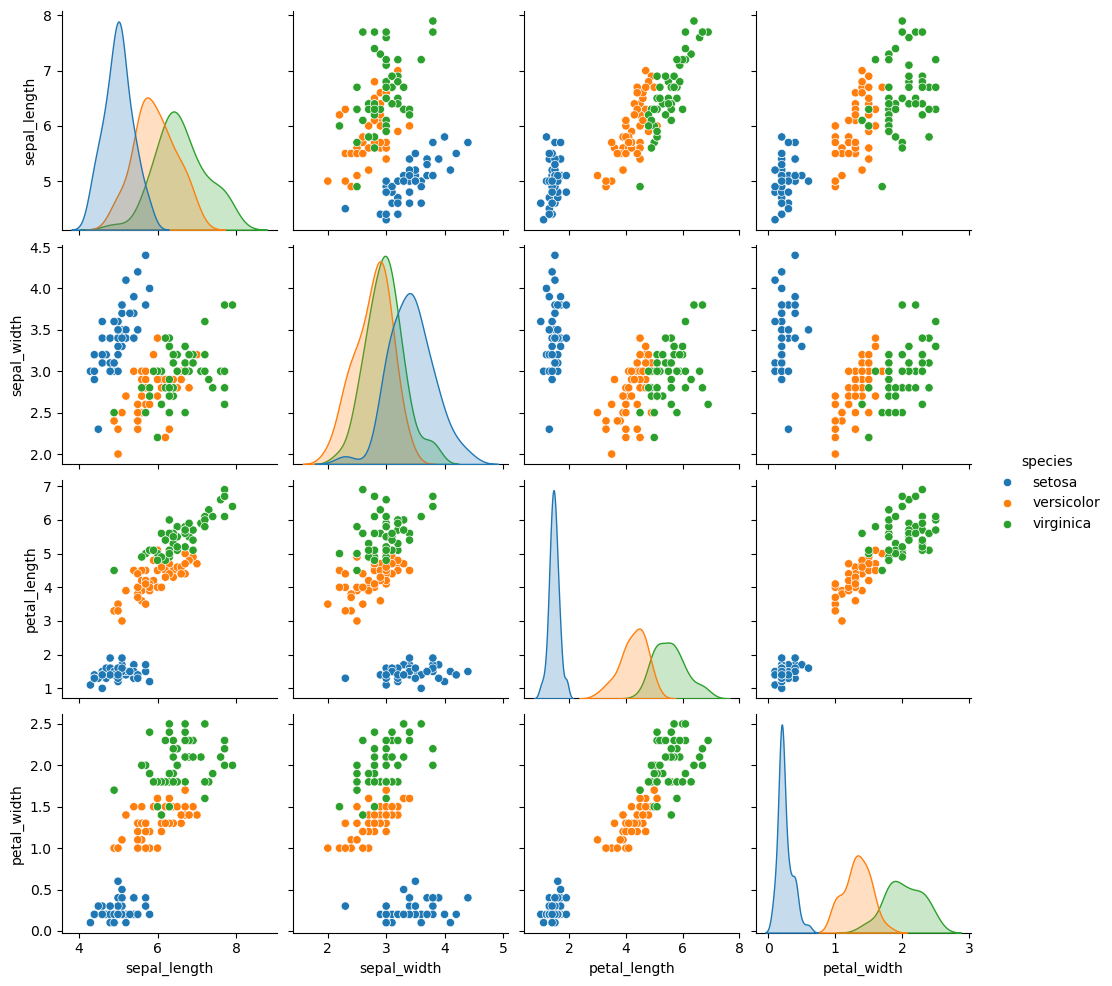

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
# Load the iris dataset
iris_df = sns.load_dataset('iris')
# Pair plot-using'species' instead of 'Species'
sns.pairplot(iris_df, hue='species')
# Save the figure
plt.savefig("exercise2a.png")
# Display the figure
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = iris_df['species'].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.9,
    random_state=1,
    stratify=y
)

In [8]:
from sklearn import tree

clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)

In [13]:
from sklearn.metrics import classification_report

prediction = clf.predict(X_test)

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       0.83      1.00      0.91         5
   virginica       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.94      0.93      0.93        15
weighted avg       0.94      0.93      0.93        15



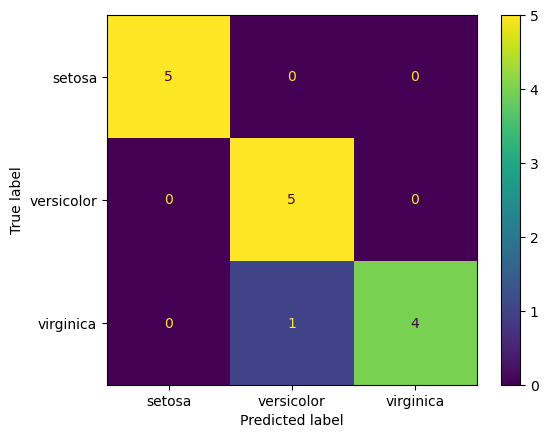

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# Create and display confusion matrix directly from classifier
ConfusionMatrixDisplay.from_estimator(clf,X_test,y_test)
plt.savefig("exercise2b.png")
plt.show()

In [15]:
!pip install pydotplus
!pip install graphviz

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'pydotplus' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pydotplus'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24636 sha256=db086b1862e279af6d60e7010dc306fa34df7ec31897351de0243c89cb015db0
  Stored in directory: /home/ip/snap/jupyterlab-desktop/common/.cache/pip/wheels/77/54/7c/c8077b6151c819495492300386cf9b151a954259d1a658c63b
Successfully built pydotplus

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.1.2


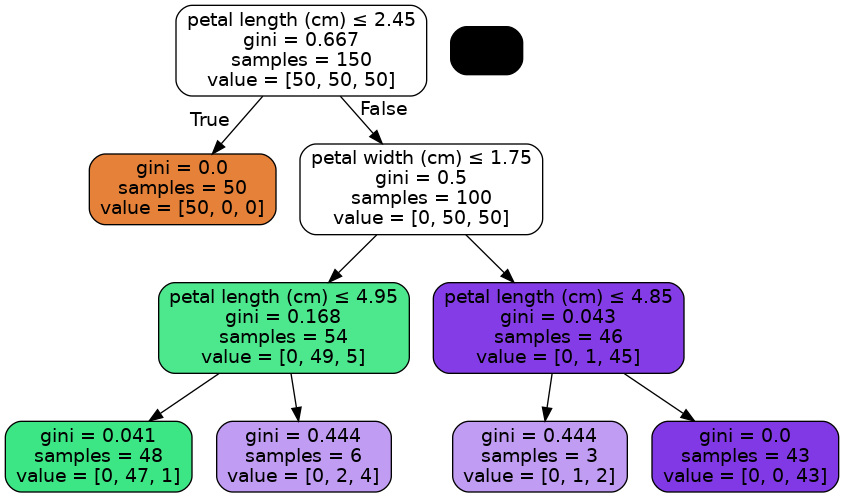

In [1]:
from io import StringIO
from IPython.display import Image
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import pydotplus

iris = load_iris()
X = iris.data
y = iris.target

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)

dot_data = StringIO()

export_graphviz(
    clf,
    out_file=dot_data,
    feature_names=['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png("exercise2c.png")

Image(graph.create_png())

In [4]:
SepalLengthCm = 4.8
SepalWidthCm = 2.9
PetalLengthCm = 1.3
PetalWidthCm = 0.2

x = [[SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]]

res = clf.predict(x)

class_mapping = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

predicted_class = class_mapping[res[0]]

print("The class predicted is --> " + predicted_class)

The class predicted is --> setosa
